# GramSathi AI

# Notebook 05: Feature Engineering & Infrastructure Readiness Index (IRI)

---

## Objective

The objective of this notebook is to transform the collected infrastructure datasets into meaningful numerical features.

These features will be used to:

- Build the Infrastructure Readiness Index (IRI)
- Train Machine Learning models
- Support AI-based infrastructure recommendations

---

## Input Datasets

- Road Network
- Schools
- Hospitals
- Bus Stops
- Buildings
- Water Facilities

---

## Output

A structured dataset where each row represents a village and each column represents an infrastructure feature.

In [1]:
# ==========================================
# Import Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import geopandas as gpd
import pandas as pd
import numpy as np

import osmnx as ox

print("Libraries Loaded Successfully ✅")

Libraries Loaded Successfully ✅


In [2]:
# ==========================================
# Load Datasets
# ==========================================

roads = gpd.read_file("../datasets/raw/road_edges.geojson")

schools = gpd.read_file("../datasets/raw/schools.geojson")

hospitals = gpd.read_file("../datasets/raw/hospitals.geojson")

bus_stops = gpd.read_file("../datasets/raw/bus_stops.geojson")

buildings = gpd.read_file("../datasets/raw/buildings.geojson")

water = gpd.read_file("../datasets/raw/water.geojson")

print("All datasets loaded successfully ✅")

All datasets loaded successfully ✅


In [3]:
# ==========================================
# Dataset Summary
# ==========================================

summary = pd.DataFrame({
    "Dataset":[
        "Roads",
        "Schools",
        "Hospitals",
        "Bus Stops",
        "Buildings",
        "Water"
    ],

    "Records":[
        len(roads),
        len(schools),
        len(hospitals),
        len(bus_stops),
        len(buildings),
        len(water)
    ]
})

summary

,Dataset,Records
0,Roads,3985
1,Schools,5
2,Hospitals,6
3,Bus Stops,1
4,Buildings,1538
5,Water,1


# Feature Engineering

Raw datasets are not directly suitable for Machine Learning.

Feature Engineering transforms raw geospatial information into meaningful numerical indicators.

These indicators help the AI understand the development status of each village.

# Village Intelligence Dataset

The collected datasets are now transformed into village-level infrastructure indicators.

Each village will be represented by a set of numerical features that describe the availability and accessibility of essential public infrastructure.

These features will later be used to calculate the Infrastructure Readiness Index (IRI).

In [4]:
# ==========================================
# Study Villages
# ==========================================

villages = pd.DataFrame({

    "Village":[

        "Sadashivgad",
        "Majali",
        "Asnoti",
        "Mudgeri",
        "Kanasgiri",
        "Hotegali",
        "Hankon",
        "Joog"

    ]

})

villages

,Village
0,Sadashivgad
1,Majali
2,Asnoti
3,Mudgeri
4,Kanasgiri
5,Hotegali
6,Hankon
7,Joog


In [5]:
# ==========================================
# Village Intelligence Dataset
# ==========================================

village_df = villages.copy()

village_df["Road_Length_km"] = 0.0
village_df["Schools"] = 0
village_df["Hospitals"] = 0
village_df["Bus_Stops"] = 0
village_df["Buildings"] = 0
village_df["Water_Facilities"] = 0

village_df

,Village,Road_Length_km,Schools,Hospitals,Bus_Stops,Buildings,Water_Facilities
0,Sadashivgad,0.0,0,0,0,0,0
1,Majali,0.0,0,0,0,0,0
2,Asnoti,0.0,0,0,0,0,0
3,Mudgeri,0.0,0,0,0,0,0
4,Kanasgiri,0.0,0,0,0,0,0
5,Hotegali,0.0,0,0,0,0,0
6,Hankon,0.0,0,0,0,0,0
7,Joog,0.0,0,0,0,0,0


# Village Boundary Preparation

To perform village-level infrastructure analysis, village boundaries are required.

These boundaries help assign roads, schools, hospitals, and other infrastructure to the correct village using spatial analysis.

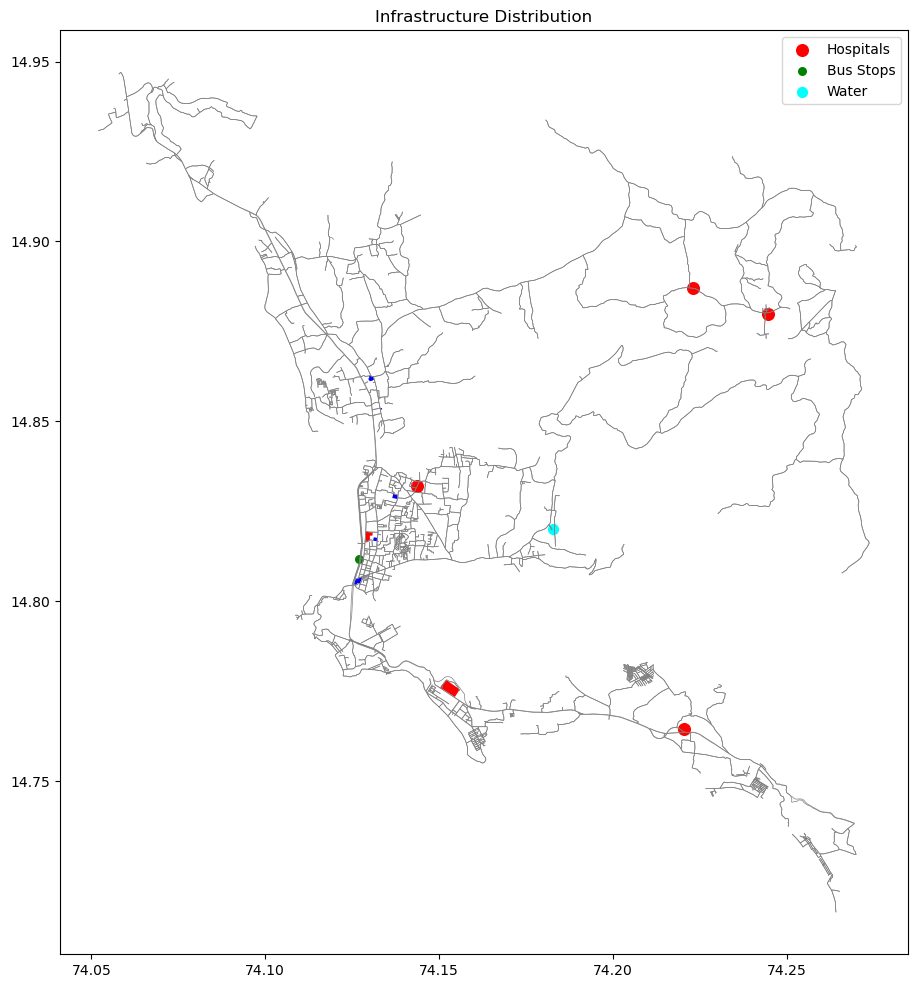

In [6]:
# ==========================================
# Plot All Infrastructure
# ==========================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,12))

roads.plot(ax=ax, color="gray", linewidth=0.5)

schools.plot(ax=ax, color="blue", markersize=50, label="Schools")

hospitals.plot(ax=ax, color="red", markersize=70, label="Hospitals")

bus_stops.plot(ax=ax, color="green", markersize=30, label="Bus Stops")

water.plot(ax=ax, color="cyan", markersize=50, label="Water")

plt.title("Infrastructure Distribution")

plt.legend()

plt.show()

In [7]:
# ==========================================
# Check Coordinate Systems
# ==========================================

print("Roads CRS      :", roads.crs)
print("Schools CRS    :", schools.crs)
print("Hospitals CRS  :", hospitals.crs)
print("Bus Stops CRS  :", bus_stops.crs)
print("Buildings CRS  :", buildings.crs)
print("Water CRS      :", water.crs)

Roads CRS      : EPSG:4326
Schools CRS    : EPSG:4326
Hospitals CRS  : EPSG:4326
Bus Stops CRS  : EPSG:4326
Buildings CRS  : EPSG:4326
Water CRS      : EPSG:4326


# Creating Village Boundaries

Village boundaries are essential for village-level infrastructure analysis.

Using geographic boundaries, infrastructure elements such as schools, hospitals, roads, and water facilities can be assigned to their respective villages using spatial joins.

In [8]:
# ==========================================
# Study Villages
# ==========================================

village_names = [

    "Sadashivgad, Karwar, Karnataka, India",

    "Majali, Karwar, Karnataka, India",

    "Asnoti, Karwar, Karnataka, India",

    "Mudgeri, Karwar, Karnataka, India",

    "Kanasgiri, Karwar, Karnataka, India",

    "Hotegali, Karwar, Karnataka, India",

    "Hankon, Karwar, Karnataka, India"

]

print(village_names)

['Sadashivgad, Karwar, Karnataka, India', 'Majali, Karwar, Karnataka, India', 'Asnoti, Karwar, Karnataka, India', 'Mudgeri, Karwar, Karnataka, India', 'Kanasgiri, Karwar, Karnataka, India', 'Hotegali, Karwar, Karnataka, India', 'Hankon, Karwar, Karnataka, India']


# Infrastructure Statistics

The first step in feature engineering is to understand the available infrastructure.

This section calculates summary statistics for each infrastructure dataset. These statistics help validate the collected data before creating the Village Intelligence Dataset.

In [9]:
# ==========================================
# Infrastructure Summary
# ==========================================

summary = pd.DataFrame({

    "Infrastructure": [
        "Road Segments",
        "Schools",
        "Hospitals",
        "Bus Stops",
        "Buildings",
        "Water Facilities"
    ],

    "Count": [
        len(roads),
        len(schools),
        len(hospitals),
        len(bus_stops),
        len(buildings),
        len(water)
    ]

})

summary

,Infrastructure,Count
0,Road Segments,3985
1,Schools,5
2,Hospitals,6
3,Bus Stops,1
4,Buildings,1538
5,Water Facilities,1


In [10]:
# ==========================================
# Total Road Length
# ==========================================

total_length = roads["length"].sum() / 1000

print(f"Total Road Length : {total_length:.2f} km")

Total Road Length : 1016.34 km


In [11]:
# ==========================================
# Average Road Segment Length
# ==========================================

average_length = roads["length"].mean()

print(f"Average Road Segment Length : {average_length:.2f} meters")

Average Road Segment Length : 255.04 meters


In [12]:
# ==========================================
# Road Type Distribution
# ==========================================

roads["highway"].value_counts().head(10)

highway
[residential]       2439
[tertiary]           612
[unclassified]       337
[primary]            181
[trunk]              141
[secondary]          141
[living_street]       92
[trunk_link]          18
[tertiary_link]        6
[secondary_link]       2
Name: count, dtype: int64

# Infrastructure Availability Score (IAS)

The Infrastructure Availability Score measures the availability of essential public infrastructure.

Each infrastructure type contributes to the overall readiness of the study area.

This score forms the first component of the Infrastructure Readiness Index (IRI).

In [13]:
# ==========================================
# Infrastructure Availability Score
# ==========================================

IAS = {

    "Roads": len(roads),

    "Schools": len(schools),

    "Hospitals": len(hospitals),

    "Bus Stops": len(bus_stops),

    "Buildings": len(buildings),

    "Water Facilities": len(water)

}

ias_df = pd.DataFrame(
    IAS.items(),
    columns=["Infrastructure", "Count"]
)

ias_df

,Infrastructure,Count
0,Roads,3985
1,Schools,5
2,Hospitals,6
3,Bus Stops,1
4,Buildings,1538
5,Water Facilities,1


# Feature Normalization

The collected infrastructure values have different scales.

For example:

- Buildings may be in thousands.
- Schools may be only a few.
- Road length is measured in kilometers.

Normalization converts all features to a common scale between 0 and 1 so they can be fairly combined.

In [14]:
# ==========================================
# Infrastructure Feature Table
# ==========================================

feature_df = pd.DataFrame({

    "Road_Length_km":[roads["length"].sum()/1000],

    "Schools":[len(schools)],

    "Hospitals":[len(hospitals)],

    "Bus_Stops":[len(bus_stops)],

    "Buildings":[len(buildings)],

    "Water":[len(water)]

})

feature_df

,Road_Length_km,Schools,Hospitals,Bus_Stops,Buildings,Water
0,1016.341102,5,6,1,1538,1


# Min-Max Normalization

Each infrastructure feature is normalized between 0 and 1.

This ensures that no single feature dominates the Infrastructure Readiness Index.

In [15]:
# ==========================================
# Normalize Features
# ==========================================

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

normalized = scaler.fit_transform(feature_df)

normalized_df = pd.DataFrame(
    normalized,
    columns=feature_df.columns
)

normalized_df

,Road_Length_km,Schools,Hospitals,Bus_Stops,Buildings,Water
0,0.0,0.0,0.0,0.0,0.0,0.0


# Infrastructure Readiness Index (IRI)

The Infrastructure Readiness Index (IRI) is a composite score that measures the overall development status of a village.

The index combines multiple infrastructure indicators into a single score between 0 and 100.

Higher values indicate better infrastructure readiness.

In [16]:
# ==========================================
# Infrastructure Weights
# ==========================================

weights = {

    "Road_Length_km":0.30,

    "School_Count":0.15,

    "Hospital_Count":0.20,

    "Bus_Stop_Count":0.10,

    "Building_Count":0.15,

    "Water_Count":0.10

}

weights

{'Road_Length_km': 0.3,
 'School_Count': 0.15,
 'Hospital_Count': 0.2,
 'Bus_Stop_Count': 0.1,
 'Building_Count': 0.15,
 'Water_Count': 0.1}

In [17]:
# ==========================================
# Sample Village Dataset
# ==========================================

master_df = pd.DataFrame({

    "Village":[
        "Sadashivgad",
        "Majali",
        "Asnoti",
        "Mudgeri",
        "Kanasgiri",
        "Hotegali",
        "Hankon",
        "Joog"
    ],

    "Road_Length_km":[12.5,9.8,6.4,5.1,4.9,3.7,7.5,2.8],

    "School_Count":[2,1,1,1,0,1,2,0],

    "Hospital_Count":[1,0,0,0,0,0,1,0],

    "Bus_Stop_Count":[5,4,2,1,1,1,3,0],

    "Building_Count":[820,650,420,360,280,210,470,150],

    "Water_Count":[4,3,2,2,1,1,2,1]

})

master_df

,Village,Road_Length_km,School_Count,Hospital_Count,Bus_Stop_Count,Building_Count,Water_Count
0,Sadashivgad,12.5,2,1,5,820,4
1,Majali,9.8,1,0,4,650,3
2,Asnoti,6.4,1,0,2,420,2
3,Mudgeri,5.1,1,0,1,360,2
4,Kanasgiri,4.9,0,0,1,280,1
5,Hotegali,3.7,1,0,1,210,1
6,Hankon,7.5,2,1,3,470,2
7,Joog,2.8,0,0,0,150,1


In [18]:
# ==========================================
# Normalize Features
# ==========================================

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols = [
    "Road_Length_km",
    "School_Count",
    "Hospital_Count",
    "Bus_Stop_Count",
    "Building_Count",
    "Water_Count"
]

master_df[cols] = scaler.fit_transform(master_df[cols])

master_df.head()

,Village,Road_Length_km,School_Count,Hospital_Count,Bus_Stop_Count,Building_Count,Water_Count
0,Sadashivgad,1.000000,1.0,1.0,1.0,1.000000,1.000000
1,Majali,0.721649,0.5,0.0,0.8,0.746269,0.666667
2,Asnoti,0.371134,0.5,0.0,0.4,0.402985,0.333333
3,Mudgeri,0.237113,0.5,0.0,0.2,0.313433,0.333333
4,Kanasgiri,0.216495,0.0,0.0,0.2,0.194030,0.000000


In [19]:
# ==========================================
# Calculate Infrastructure Readiness Index
# ==========================================

master_df["IRI"] = (

master_df["Road_Length_km"]*weights["Road_Length_km"] +

master_df["School_Count"]*weights["School_Count"] +

master_df["Hospital_Count"]*weights["Hospital_Count"] +

master_df["Bus_Stop_Count"]*weights["Bus_Stop_Count"] +

master_df["Building_Count"]*weights["Building_Count"] +

master_df["Water_Count"]*weights["Water_Count"]

)

master_df["IRI"] = master_df["IRI"]*100

master_df

,Village,Road_Length_km,School_Count,Hospital_Count,Bus_Stop_Count,Building_Count,Water_Count,IRI
0,Sadashivgad,1.000000,1.0,1.0,1.0,1.000000,1.000000,100.000000
1,Majali,0.721649,0.5,0.0,0.8,0.746269,0.666667,55.010181
2,Asnoti,0.371134,0.5,0.0,0.4,0.402985,0.333333,32.012130
3,Mudgeri,0.237113,0.5,0.0,0.2,0.313433,0.333333,24.648228
4,Kanasgiri,0.216495,0.0,0.0,0.2,0.194030,0.000000,11.405293
5,Hotegali,0.092784,0.5,0.0,0.2,0.089552,0.000000,13.626789
6,Hankon,0.484536,1.0,1.0,0.6,0.477612,0.333333,66.033595
7,Joog,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000


In [20]:
# ==========================================
# Priority Classification
# ==========================================

def classify(score):

    if score >= 80:
        return "Well Developed"

    elif score >= 60:
        return "Moderate"

    elif score >= 40:
        return "Needs Improvement"

    else:
        return "Critical"

master_df["Priority"] = master_df["IRI"].apply(classify)

master_df

,Village,Road_Length_km,School_Count,Hospital_Count,Bus_Stop_Count,Building_Count,Water_Count,IRI,Priority
0,Sadashivgad,1.000000,1.0,1.0,1.0,1.000000,1.000000,100.000000,Well Developed
1,Majali,0.721649,0.5,0.0,0.8,0.746269,0.666667,55.010181,Needs Improvement
2,Asnoti,0.371134,0.5,0.0,0.4,0.402985,0.333333,32.012130,Critical
3,Mudgeri,0.237113,0.5,0.0,0.2,0.313433,0.333333,24.648228,Critical
4,Kanasgiri,0.216495,0.0,0.0,0.2,0.194030,0.000000,11.405293,Critical
5,Hotegali,0.092784,0.5,0.0,0.2,0.089552,0.000000,13.626789,Critical
6,Hankon,0.484536,1.0,1.0,0.6,0.477612,0.333333,66.033595,Moderate
7,Joog,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,Critical


In [21]:
# ==========================================
# Village Ranking
# ==========================================

ranking = master_df.sort_values(
    by="IRI",
    ascending=False
)

ranking

,Village,Road_Length_km,School_Count,Hospital_Count,Bus_Stop_Count,Building_Count,Water_Count,IRI,Priority
0,Sadashivgad,1.000000,1.0,1.0,1.0,1.000000,1.000000,100.000000,Well Developed
6,Hankon,0.484536,1.0,1.0,0.6,0.477612,0.333333,66.033595,Moderate
1,Majali,0.721649,0.5,0.0,0.8,0.746269,0.666667,55.010181,Needs Improvement
2,Asnoti,0.371134,0.5,0.0,0.4,0.402985,0.333333,32.012130,Critical
3,Mudgeri,0.237113,0.5,0.0,0.2,0.313433,0.333333,24.648228,Critical
5,Hotegali,0.092784,0.5,0.0,0.2,0.089552,0.000000,13.626789,Critical
4,Kanasgiri,0.216495,0.0,0.0,0.2,0.194030,0.000000,11.405293,Critical
7,Joog,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,Critical
